In [1]:
import pandas as pd

df1 = pd.read_csv('smart_meter_data (1).csv')
df1.head()

,datetime,msn,location,daily_consumption_load,energy_supplied,energy_billed
0,2021-01-01 00:00:00,ACE43B7D,Chennai,2.59,2.78,2.57
1,2021-01-01 00:15:00,ACE43B7D,Chennai,1.78,2.12,1.86
2,2021-01-01 00:30:00,ACE43B7D,Chennai,2.59,2.68,2.52
3,2021-01-01 00:45:00,ACE43B7D,Chennai,2.45,2.56,2.50
4,2021-01-01 01:00:00,ACE43B7D,Chennai,1.48,1.56,1.49


In [2]:
df1.columns

Index(['datetime', 'msn', 'location', 'daily_consumption_load',
       'energy_supplied', 'energy_billed'],
      dtype='object')

In [3]:
df = df1.groupby('msn').apply(lambda x: x.sample(frac=0.1, random_state=42)).reset_index(drop=True)

print(f"Original dataset shape: {df1.shape}")
print(f"Sampled dataset shape: {df.shape}")
print(f"Unique msn values in sampled data: {df['msn'].nunique()}")

Original dataset shape: (525600, 6)
Sampled dataset shape: (52560, 6)
Unique msn values in sampled data: 5


C:\Users\HP\AppData\Local\Temp\ipykernel_2336\1815610046.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df1.groupby('msn').apply(lambda x: x.sample(frac=0.1, random_state=42)).reset_index(drop=True)


In [4]:
#import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [5]:


df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').set_index('datetime')

target_series = df['daily_consumption_load']


scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(target_series.values.reshape(-1, 1))


In [6]:


def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])  # Past 'seq_length' values
        y.append(data[i, 0])               # The next value
    return np.array(X), np.array(y)

SEQ_LENGTH = 10  
X, y = create_sequences(scaled_data, SEQ_LENGTH)


X = X.reshape((X.shape[0], X.shape[1], 1))



In [7]:



train_size = int(len(X) * 0.8)

X_train, y_train = X, y

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1)) # Output layer

model.compile(optimizer='adam', loss='mean_squared_error')


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
pip install graphviz

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [10]:
from tensorflow.keras.utils import plot_model

# Create a visual plot of the model architecture
plot_model(model, 
           to_file='model_architecture.png',
           show_shapes=True,
           show_layer_names=True,
           show_layer_activations=True,
           dpi=96)

# Or display directly in notebook
plot_model(model, show_shapes=True, show_layer_activations=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [20]:


history = model.fit(X_train, y_train, epochs=5, batch_size=1, verbose=1)


train_predict = model.predict(X_train)
# Invert scaling back to original units
train_predict = scaler.inverse_transform(train_predict)
y_train_actual = scaler.inverse_transform(y.reshape(-1, 1))


Epoch 1/5
52550/52550 ━━━━━━━━━━━━━━━━━━━━ 211s 4ms/step - loss: 0.0665
Epoch 2/5
52550/52550 ━━━━━━━━━━━━━━━━━━━━ 134s 3ms/step - loss: 0.0660
Epoch 3/5
52550/52550 ━━━━━━━━━━━━━━━━━━━━ 140s 3ms/step - loss: 0.0659
Epoch 4/5
52550/52550 ━━━━━━━━━━━━━━━━━━━━ 137s 3ms/step - loss: 0.0659
Epoch 5/5
52550/52550 ━━━━━━━━━━━━━━━━━━━━ 299s 6ms/step - loss: 0.0659
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


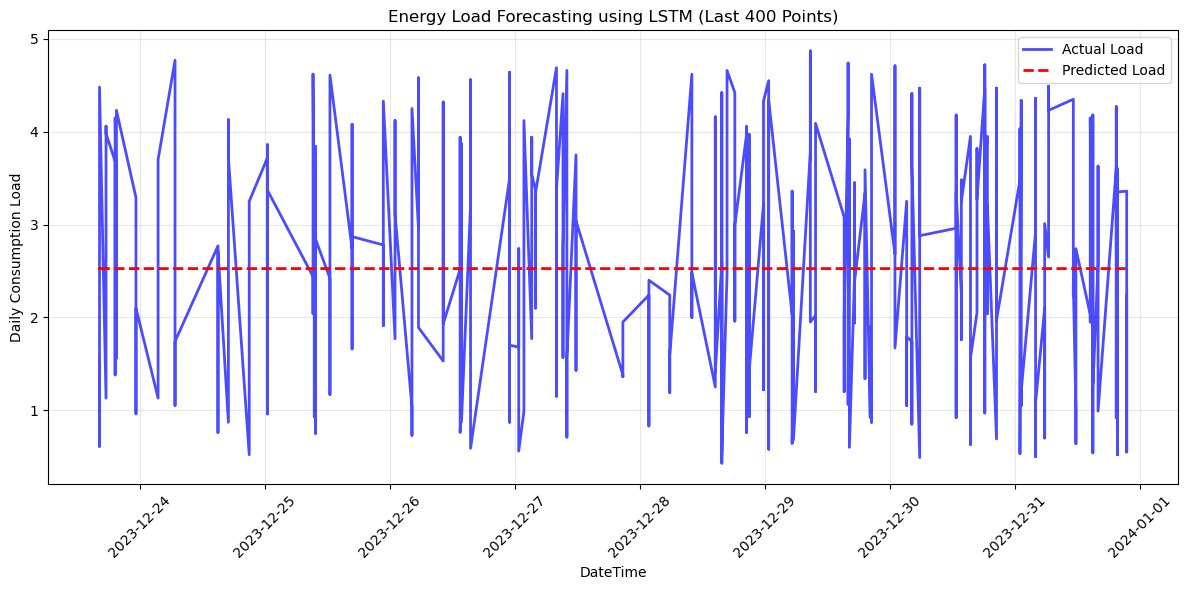

In [29]:
plt.figure(figsize=(12,6))

# Get the last 40 points from each array
last_n_points = 400

# Plot last 40 actual values
plt.plot(df.index[-last_n_points:], 
         y_train_actual[-last_n_points:], 
         label='Actual Load', color='blue', alpha=0.7, linewidth=2)

# Plot last 40 predicted values
plt.plot(df.index[-last_n_points:], 
         train_predict[-last_n_points:], 
         label='Predicted Load', color='red', linestyle='--', linewidth=2)

plt.title(f'Energy Load Forecasting using LSTM (Last {last_n_points} Points)')
plt.xlabel('DateTime')
plt.ylabel('Daily Consumption Load')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

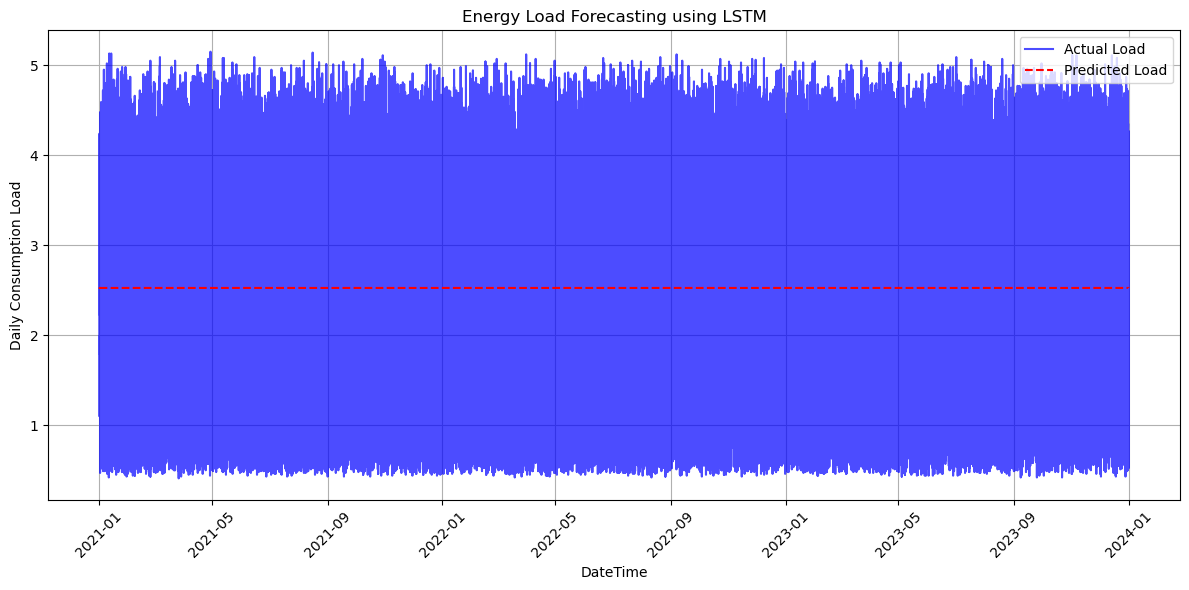

Mean Absolute Error (MAE): 1.05
Root Mean Squared Error (RMSE): 1.22

Model training and demonstration complete. For a real project, use a larger dataset.


In [ ]:

# --- Visualization ---
plt.figure(figsize=(12,6))
# Plot actual values
plt.plot(df.index[SEQ_LENGTH:], y_train_actual, label='Actual Load', color='blue', alpha=0.7)
# Plot predicted values
plt.plot(df.index[SEQ_LENGTH:], train_predict, label='Predicted Load', color='red', linestyle='--')
plt.title('Energy Load Forecasting using LSTM')
plt.xlabel('DateTime')
plt.ylabel('Daily Consumption Load')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Model Evaluation ---
mae = mean_absolute_error(y_train_actual, train_predict)
rmse = np.sqrt(mean_squared_error(y_train_actual, train_predict))
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


In [26]:
def calculate_mape(actual, predicted):
    """Calculate Mean Absolute Percentage Error"""
    # Avoid division by zero
    actual, predicted = np.array(actual), np.array(predicted)
    non_zero_mask = actual != 0
    if np.sum(non_zero_mask) == 0:
        return np.inf  # Return infinity if all actual values are zero
    return np.mean(np.abs((actual[non_zero_mask] - predicted[non_zero_mask]) / actual[non_zero_mask])) * 100

In [27]:
mae = mean_absolute_error(y_train_actual, train_predict)
rmse = np.sqrt(mean_squared_error(y_train_actual, train_predict))
mape = calculate_mape(y_train_actual, train_predict)

# Print results
print("=" * 50)
print("MODEL EVALUATION METRICS")
print("=" * 50)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print("=" * 50)

MODEL EVALUATION METRICS
Mean Absolute Error (MAE): 1.0493
Root Mean Squared Error (RMSE): 1.2161
Mean Absolute Percentage Error (MAPE): 67.87%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


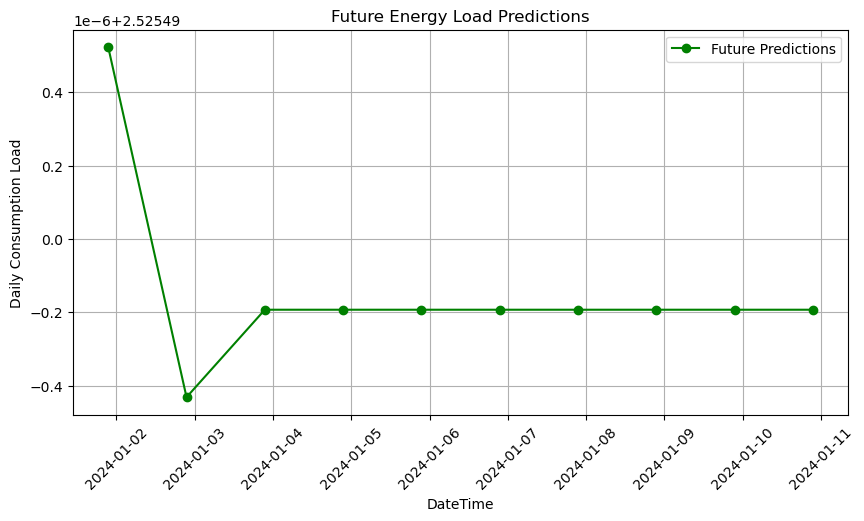

In [22]:

# --- Forecasting Future Values ---
last_sequence = X_train[-1]  # Get the last sequence from training data
future_steps = 10
future_predictions = []

for _ in range(future_steps):
    # Reshape and predict the next value
    input_seq = last_sequence.reshape((1, SEQ_LENGTH, 1))
    next_pred = model.predict(input_seq)
    future_predictions.append(next_pred[0, 0])
    # Update the last_sequence to include the new prediction
    last_sequence = np.append(last_sequence[1:], next_pred)

future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=future_steps)
plt.figure(figsize=(10,5))
plt.plot(future_dates, future_predictions, marker='o', label='Future Predictions', color='green')
plt.title('Future Energy Load Predictions')
plt.xlabel('DateTime')
plt.ylabel('Daily Consumption Load')
plt.legend()
plt.grid(True)  
plt.xticks(rotation=45)
plt.show()

Future Predictions (next 150 minutes):
                     predicted_load
datetime                           
2023-12-31 21:45:00        2.525491
2023-12-31 22:00:00        2.525490
2023-12-31 22:15:00        2.525490
2023-12-31 22:30:00        2.525490
2023-12-31 22:45:00        2.525490
2023-12-31 23:00:00        2.525490
2023-12-31 23:15:00        2.525490
2023-12-31 23:30:00        2.525490
2023-12-31 23:45:00        2.525490
2024-01-01 00:00:00        2.525490


C:\Users\HP\AppData\Local\Temp\ipykernel_6428\3202996811.py:21: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  future_timestamps = pd.date_range(


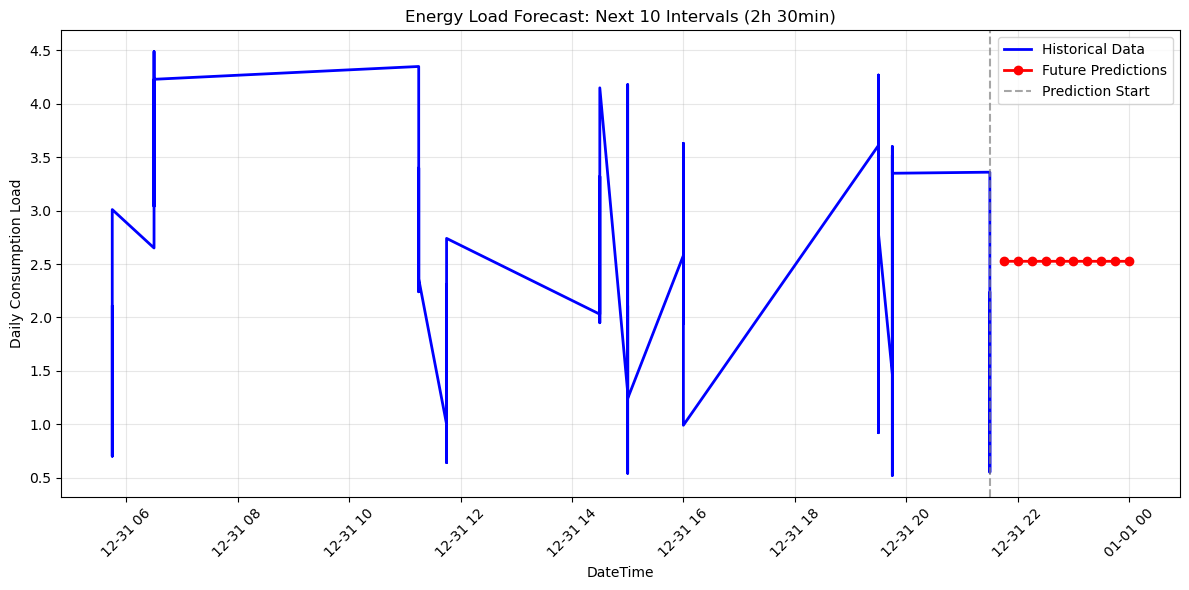

In [23]:

last_sequence = X_train[-1]  # Get the last sequence from training data
future_steps = 10  # Predicting next 10 intervals (150 minutes)
future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(future_steps):
    # Reshape and predict the next value
    input_seq = current_sequence.reshape((1, SEQ_LENGTH, 1))
    next_pred = model.predict(input_seq, verbose=0)
    future_predictions.append(next_pred[0, 0])
    
    # Update the sequence: remove first element, append new prediction
    current_sequence = np.append(current_sequence[1:], next_pred)

# Convert predictions back to original scale
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# CORRECTED: Generate future timestamps with 15-minute intervals
last_timestamp = df.index[-1]
future_timestamps = pd.date_range(
    start=last_timestamp + pd.Timedelta(minutes=15), 
    periods=future_steps, 
    freq='15T'  # 15-minute frequency
)

# Create DataFrame for future predictions
future_df = pd.DataFrame({
    'datetime': future_timestamps,
    'predicted_load': future_predictions.flatten()
})
future_df.set_index('datetime', inplace=True)

print("Future Predictions (next 150 minutes):")
print(future_df)

# --- Visualization ---
plt.figure(figsize=(12, 6))

# Plot historical data (last 50 points for context)
historical_points = 50
plt.plot(df.index[-historical_points:], 
         df['daily_consumption_load'].values[-historical_points:], 
         label='Historical Data', color='blue', linewidth=2)

# Plot future predictions
plt.plot(future_df.index, future_df['predicted_load'], 
         marker='o', label='Future Predictions', color='red', linewidth=2, markersize=6)

plt.axvline(x=last_timestamp, color='gray', linestyle='--', alpha=0.7, label='Prediction Start')
plt.title(f'Energy Load Forecast: Next {future_steps} Intervals ({(future_steps * 15)//60}h {(future_steps * 15)%60}min)')
plt.xlabel('DateTime')
plt.ylabel('Daily Consumption Load')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
df.to_csv('sampled_smart_meter_data.csv', index=False)

In [25]:
df.head()

,msn,location,daily_consumption_load,energy_supplied,energy_billed
datetime,,,,,
2021-01-01 05:45:00,3F42A75F,Mumbai,3.40,3.57,3.41
2021-01-01 05:45:00,344684B5,Kolkata,4.17,4.36,4.14
2021-01-01 05:45:00,0653DAA9,Bengaluru,1.99,2.21,1.94
2021-01-01 05:45:00,ACE43B7D,Chennai,0.69,0.74,0.66
2021-01-01 05:45:00,7F6ACD62,Delhi,1.14,1.33,1.15
